In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, pearsonr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving cleaned_soil_data.csv to cleaned_soil_data.csv
Saving cleaned_weather_data.csv to cleaned_weather_data.csv
Saving cleaned_wine_data.csv to cleaned_wine_data.csv


In [ ]:
soil_data = pd.read_csv("cleaned_soil_data.csv")
weather_data = pd.read_csv("cleaned_weather_data.csv")
wine_data = pd.read_csv("cleaned_wine_data.csv")

# 🔍 Eploratory Data Analysis - EDA


In [ ]:
def perform_eda(df, dataset_name):
    print(f"\n=== EDA for {dataset_name} ===\n")

    print("\nDataset Shape:", df.shape)
    print("\nData Types:\n", df.dtypes)

    print("\nSummary Statistics:\n", df.describe())

    print("\nMissing Values:\n", df.isnull().sum())

    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        df[numeric_cols].hist(figsize=(12, 8), bins=20, edgecolor='black')
        plt.suptitle(f"{dataset_name} - Feature Distributions")
        plt.show()

    if len(numeric_cols) > 1:
        plt.figure(figsize=(10, 6))
        sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title(f"{dataset_name} - Correlation Matrix")
        plt.show()

    plt.figure(figsize=(12, 6))
    df[numeric_cols].boxplot(rot=45)
    plt.title(f"{dataset_name} - Outlier Detection")
    plt.show()


| Column                          | Meaning                              |
|---------------------------------|--------------------------------------|
| **Lot**                         | Batch or vineyard lot               |
| **Date**                        | Sampling date                       |
| **Type**                        | Type of wine                        |
| **Azote ammoniacal (mg/l)**      | Ammoniacal nitrogen in mg/l         |
| **pH**                          | Acidity level                       |
| **Acidité totale (g H2SO4/l)**   | Total acidity in g H2SO4/l          |
| **TAV Acquis (%vol.)**          | Alcohol volume %                    |
| **SO2 Libre**                   | Free SO2                            |
| **SO2 Total**                   | Total SO2                           |
| **Glucose-Fructose**            | Sugar content                       |
| **Acidité volatile (gH2SO4/L)**  | Volatile acidity                    |
| **Acide Malique (g/l)**         | Malic acid content                  |
| **Acide lactique**              | Lactic acid content                 |
| **Azote alpha-aminé (mg/l)**     | Alpha-amino nitrogen                |
| **Densité**                     | Wine density                        |
| **Acide acétique**              | Acetic acid                         |



=== EDA for Soil Data ===


Dataset Shape: (119, 13)

Data Types:
 Sample Number                    object
Sampling Date                    object
Plot Name                        object
Depth (cm)                      float64
Temperature (Last 12 Months)    float64
Measured C.E.C. (meq/100g)      float64
Saturation level                 object
% clay (6)                      float64
Analysis type                    object
Elements types                   object
Value                           float64
Desirable (from)                float64
Desirable (to)                  float64
dtype: object

Summary Statistics:
        Depth (cm)  Temperature (Last 12 Months)  Measured C.E.C. (meq/100g)  \
count  119.000000                    119.000000                  119.000000   
mean     0.142857                      0.571429                    0.285714   
std      0.351407                      0.496964                    0.453664   
min      0.000000                      0.000000             

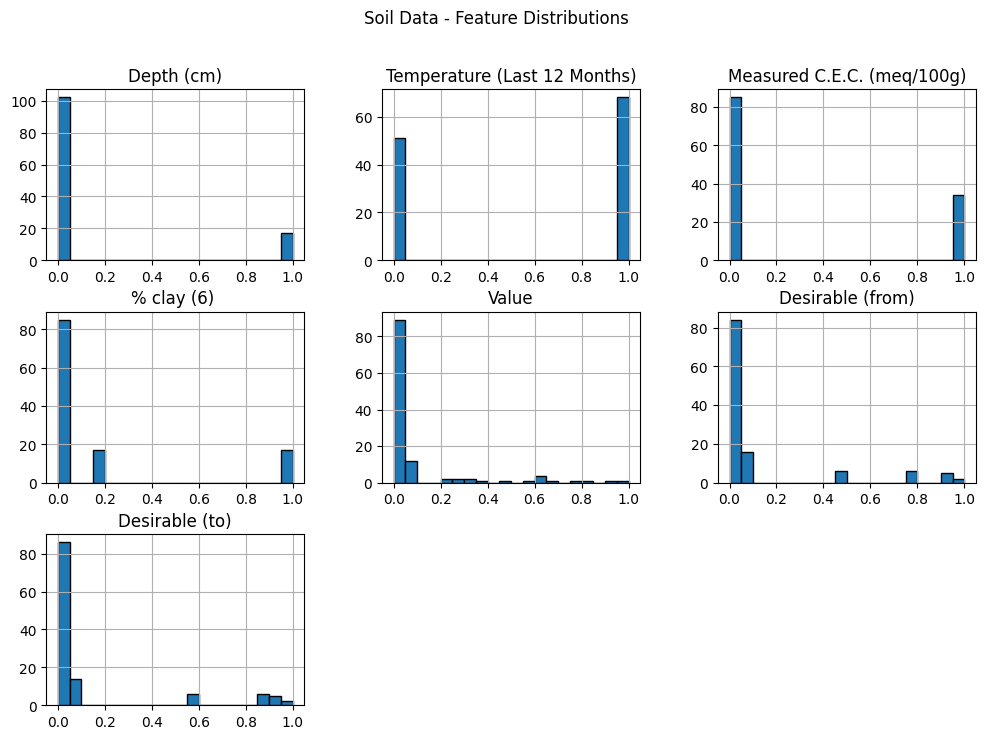

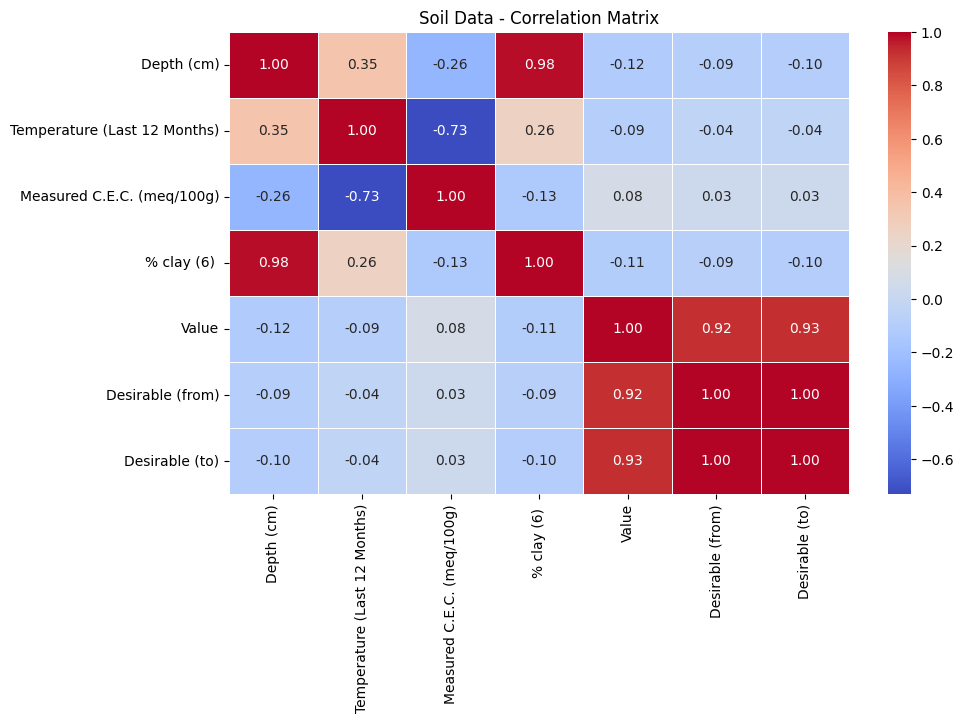

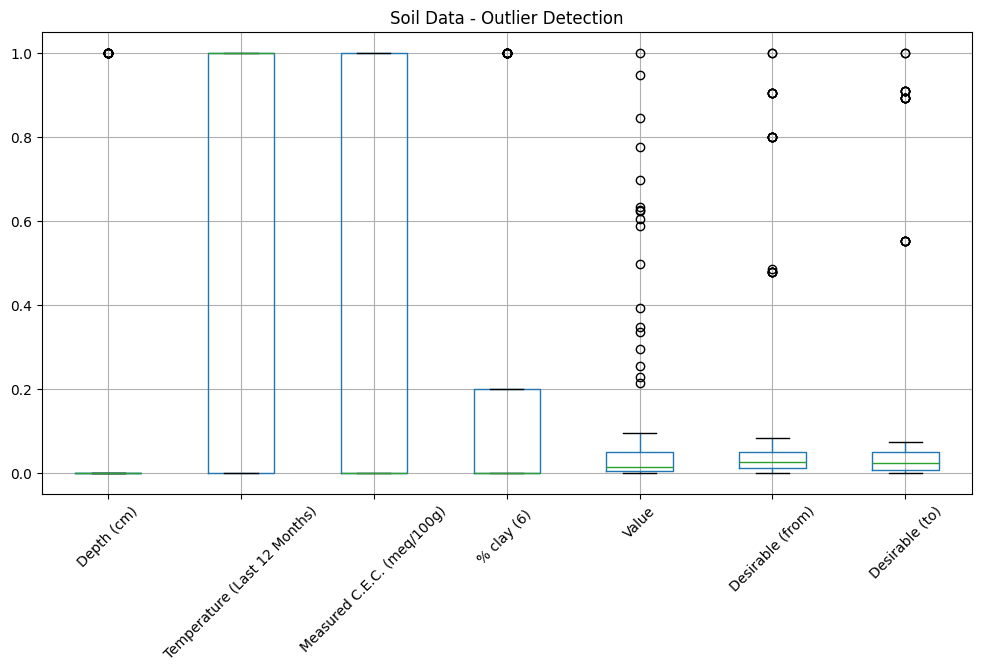

In [ ]:
perform_eda(soil_data, "Soil Data")

## **EDA Summary - Soil Data Analysis**

### **Observations**
- The dataset has **119 rows** and **13 columns**, covering soil attributes like **Depth (cm), Temperature, C.E.C. (Cation Exchange Capacity), Clay %, Analysis Type, and Element Values**.
- The **mean depth is 0.14 cm**, but the **maximum depth is 1 cm**, which shows a little bit of imbalance in depth measurements.
- Temperature has a **mean of 0.57**, which is normalized between 0 and 1.
- Similarly **C.E.C. values range between 0 and 1**
- **Strong correlations** exist between:
  - **Depth and Clay % (0.98)**: which could mean deeper soils tend to have more clay.
  - **Value and Desirable (from/to) (0.92 - 1.00)**: Suggests that the desirable range aligns well with actual measured values.

### **Irregularities**

- The **boxplot shows multiple outliers**, particularly for **Value, C.E.C., and Clay %**.
- The **correlation matrix has extreme values**, indicating highly dependent variables. This may lead to **multicollinearity issues** later in our predictive models.

------------------------------------------------


=== EDA for Weather Data ===


Dataset Shape: (2192, 9)

Data Types:
 date     object
tavg    float64
tmin    float64
tmax    float64
prcp    float64
wdir    float64
wspd    float64
wpgt    float64
pres    float64
dtype: object

Summary Statistics:
               tavg         tmin         tmax         prcp         wdir  \
count  2192.000000  2192.000000  2192.000000  2192.000000  2192.000000   
mean      0.480977     0.534517     0.449793     0.018514     0.529275   
std       0.169740     0.169754     0.171603     0.043617     0.236889   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.355366     0.408163     0.324138     0.007389     0.417827   
50%       0.473822     0.533528     0.445977     0.007389     0.571031   
75%       0.612565     0.667638     0.579310     0.007389     0.674095   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

              wspd         wpgt         pres  
count  2192.000000  2192.000000  21

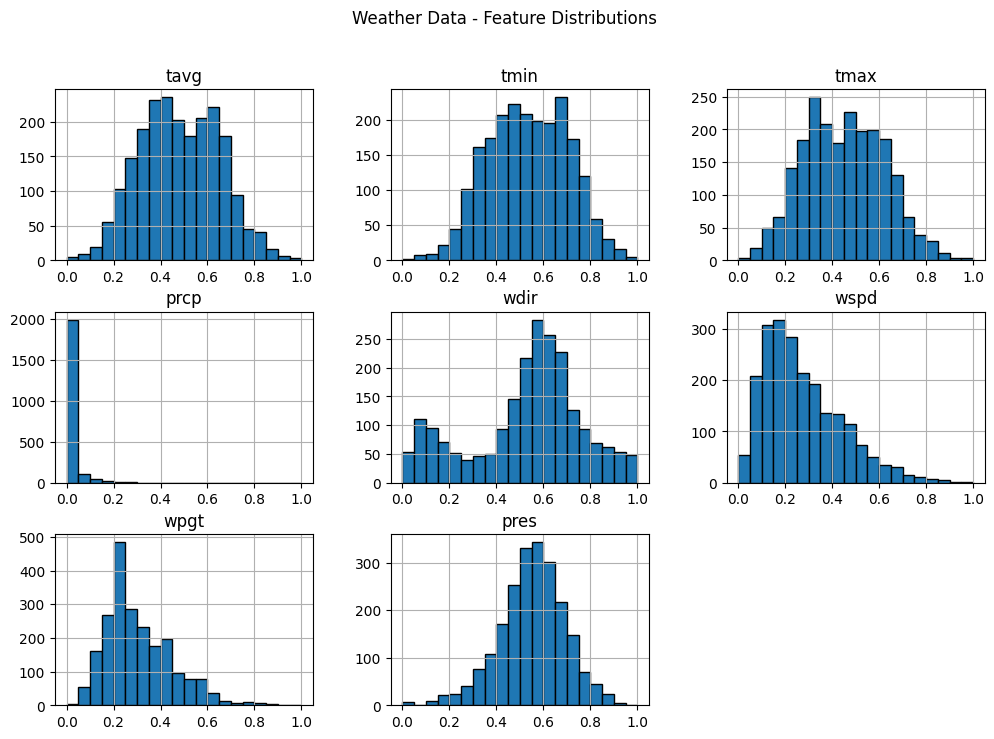

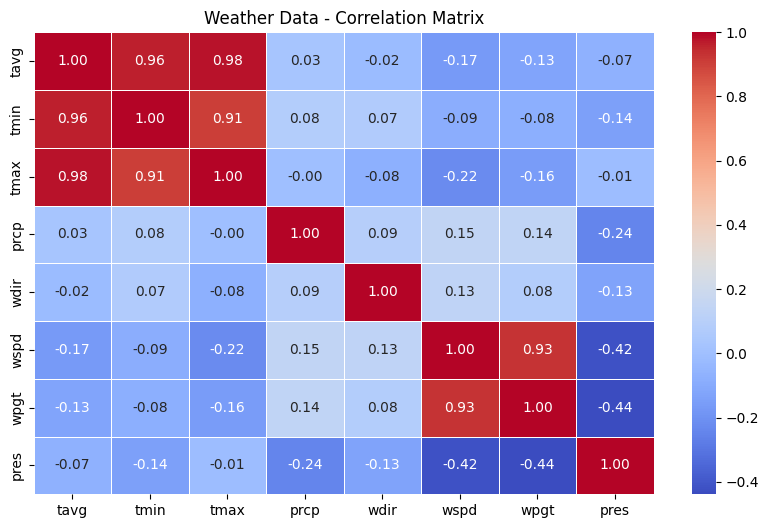

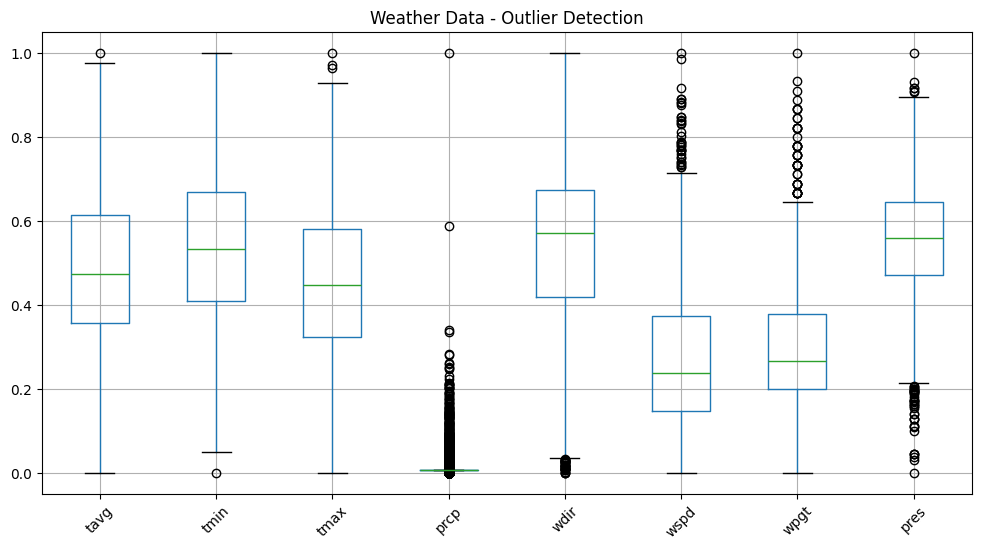

In [ ]:
perform_eda(weather_data, "Weather Data")

## **EDA Summary - Weather Data Analysis**

### **Observations**
- **2192 records**; **daily weather data for 6 years**.
- Features include **Temperature (tavg, tmin, tmax), Precipitation (prcp), Wind (wdir, wspd, wpgt), and Pressure (pres)**.
- **Mean temperatures** (tavg: 0.48, tmin: 0.53, tmax: 0.44); consistent.
- **High correlation between tavg, tmin, and tmax (0.96-0.98)**
- **Wind speed (wspd) correlates highly with wind gust (wpgt) (0.93)**

### **Irregularities**
- **Precipitation (prcp) is highly skewed**, with most values **near zero**.
  - Likely an **imbalance in rainfall days** (many dry days).
  - High **outliers**, suggesting heavy rain events.

---


=== EDA for Wine Data ===


Dataset Shape: (39, 16)

Data Types:
 Lot                             object
Date                            object
Type                            object
Azote ammoniacal (mg/l)        float64
pH                             float64
Acidité totale (g H2SO4/l)     float64
TAV Acquis (%vol.)             float64
SO2 Libre                      float64
SO2 Total                      float64
Glucose-Fructose               float64
Acidité volatile (gH2SO4/L)    float64
Acide Malique (g/l)            float64
Acide lactique                 float64
Azote alpha-aminé (mg/l)       float64
Densité                        float64
Acide acétique                 float64
dtype: object

Summary Statistics:
        Azote ammoniacal (mg/l)         pH  Acidité totale (g H2SO4/l)  \
count                39.000000  39.000000                   39.000000   
mean                  0.112100   0.622701                    0.423177   
std                   0.252516   0.331295             

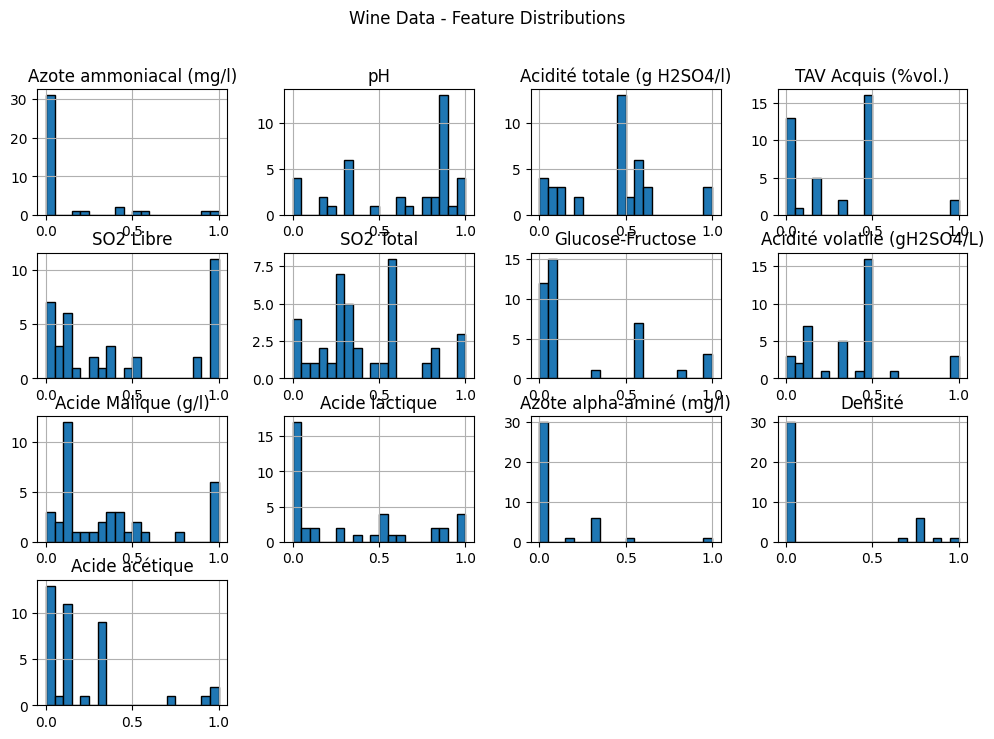

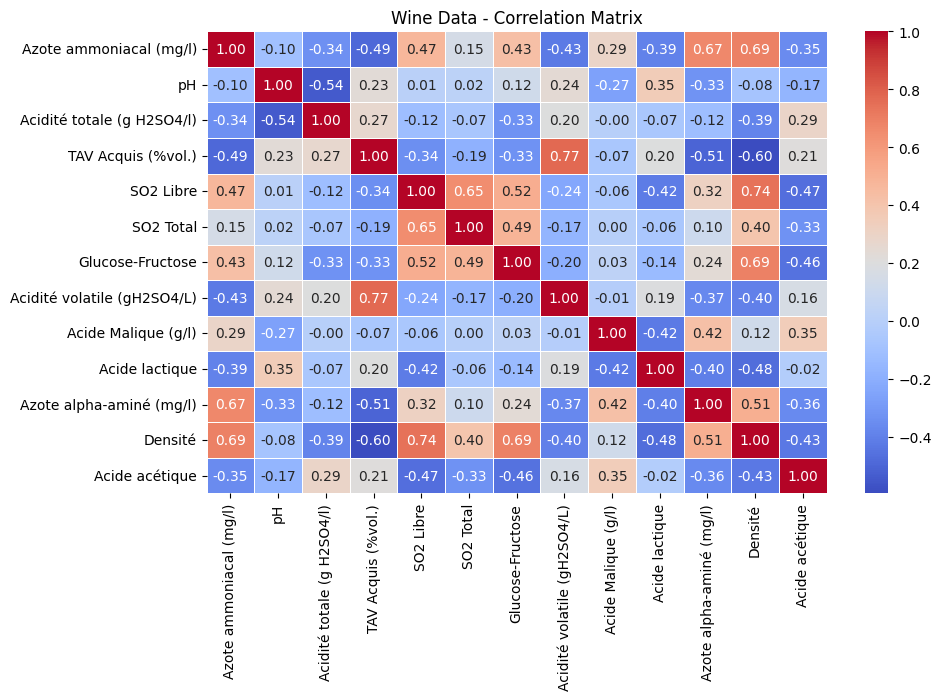

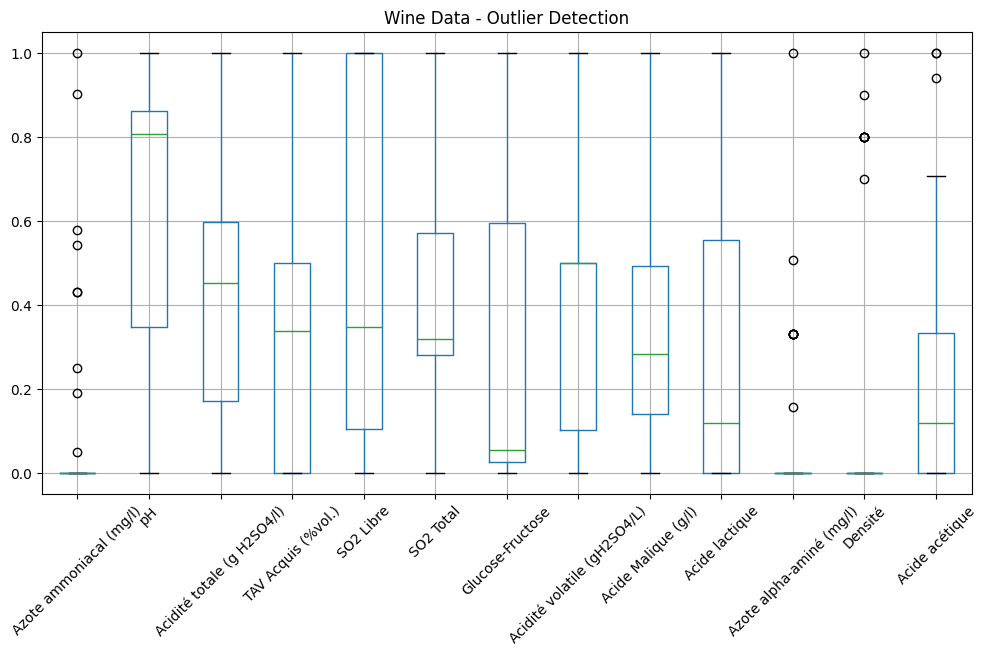

In [ ]:
perform_eda(wine_data, "Wine Data")

## **EDA Summary - Wine Data Analysis**


### **Observations**
- **39 samples**, each representing different wine batches.
- Contains chemical attributes like **pH, SO2, Glucose-Fructose, Acidity, and Alcohol (TAV Acquis)**.
- **Acidité totale is highly correlated with Acidité volatile (0.77)**, which shows a strong relationship between acidity measures.
- **SO2 Libre and SO2 Total (0.65)** indicate expected proportionality in sulfur levels.
- **Azote ammoniacal (Ammonia nitrogen) is highly correlated with Azote alpha-aminé (Amino nitrogen) (0.67)**, expected in fermentation.

### **Irregularities**
- **Outliers in SO2 and Glucose-Fructose** could indicate fermentation issues.


---


In [ ]:
print("Columns in Soil Data:", soil_data.columns)


Columns in Soil Data: Index(['Sample Number', 'Sampling Date', 'Plot Name', 'Depth (cm)',
       'Temperature (Last 12 Months)', 'Measured C.E.C. (meq/100g)',
       'Saturation level', '% clay (6) ', 'Analysis type', 'Elements types',
       'Value', 'Desirable (from)', 'Desirable (to)'],
      dtype='object')


# 📊 Feature Engineering: Defined Metrics

## 🔸 Soil Health Index (SHI)
To simplify soil evaluation, we define a **Soil Health Index (SHI)**, which represents the overall soil fertility and structure based on key attributes:

$$
SHI = (0.4 \times \text{Measured C.E.C. (meq/100g)}) + (0.3 \times \text{\% clay (6)}) + \left( 0.3 \times \frac{\text{Desirable (from)} + \text{Desirable (to)}}{2} \right)
$$

- **Measured C.E.C. (meq/100g):** Indicates soil's nutrient retention capability.
- **% Clay (6):** Affects water retention and aeration.
- **Desirable Range:** The average of recommended lower and upper limits.

This SHI score helps assess soil health and its impact on **crop yield and wine quality**. 🍇🌱

---

## 🔸 Yield Prediction Factor
This metric estimates how weather conditions impact potential **grape yield**.

$$
Yield\_Factor = (0.5 \times \text{tavg}) + (0.3 \times \text{prcp}) - (0.2 \times \text{wspd})
$$

- **tavg (Average Temperature):** Higher temperatures influence grape ripening.
- **prcp (Precipitation):** Essential for hydration but excessive rain can be harmful.
- **wspd (Wind Speed):** High wind speeds can stress vines and reduce yield.

This factor helps **predict harvest outcomes** under different weather conditions. 🌤️

---

## 🔸 Acidity Balance for Wine
Wine acidity impacts **taste, stability, and aging potential**. We define **Acidity Balance** as:

$$
Acidity\_Balance = \text{Acidité totale (g H2SO4/l)} - \text{Acidité volatile (gH2SO4/L)}
$$

- **Total Acidity:** Sum of all acids in wine, affecting sharpness and freshness.
- **Volatile Acidity:** Includes acetic acid (vinegar-like), affecting wine quality.

A balanced acidity ensures **good taste and shelf life**. 🍷

---

## 🔸 Binarized Alcohol Levels
Wines are classified into **High Alcohol** and **Low Alcohol** based on the median alcohol content:

$$
Alcohol\_Category =
\begin{cases}
\text{High Alcohol}, & \text{if } TAV Acquis (%vol.) > \text{median} \\
\text{Low Alcohol}, & \text{otherwise}
\end{cases}
$$

- **TAV Acquis (%vol.):** Represents alcohol volume in wine.
- High alcohol wines often have **fuller body** and **longer aging potential**.



In [ ]:
# Soil Health Index (SHI) - Weighted sum of key attributes
soil_data["Soil_Health_Index"] = (
    0.4 * soil_data["Measured C.E.C. (meq/100g)"] +
    0.3 * soil_data["% clay (6) "] +
    0.3 * ((soil_data["Desirable (from)"] + soil_data["Desirable (to)"]) / 2)
)

# Yield Prediction Factor - Based on soil + weather conditions
weather_data["Yield_Factor"] = (
    0.5 * weather_data["tavg"] +
    0.3 * weather_data["prcp"] -
    0.2 * weather_data["wspd"]
)

# Acidity Balance for Wine - Difference between total and volatile acidity
wine_data["Acidity_Balance"] = wine_data["Acidité totale (g H2SO4/l)"] - wine_data["Acidité volatile (gH2SO4/L)"]

# Binarize Alcohol Levels
wine_data["Alcohol_Category"] = np.where(
    wine_data["TAV Acquis (%vol.)"] > wine_data["TAV Acquis (%vol.)"].median(),
    "High Alcohol", "Low Alcohol"
)

# Save engineered datasets
soil_data.to_csv("engineered_soil_data.csv", index=False)
weather_data.to_csv("engineered_weather_data.csv", index=False)
wine_data.to_csv("engineered_wine_data.csv", index=False)

print("Feature engineering complete! Proceeding to statistical analysis...")

Feature engineering complete! Proceeding to statistical analysis...


# Statistical Analysis 📈 for Business Insights 📊


In [ ]:
anova_result = f_oneway(
    wine_data[wine_data["Alcohol_Category"] == "High Alcohol"]["Acidity_Balance"],
    wine_data[wine_data["Alcohol_Category"] == "Low Alcohol"]["Acidity_Balance"]
)
print(f"ANOVA p-value for wine acidity difference: {anova_result.pvalue:.5f}")


weather_data["date"] = pd.to_datetime(weather_data["date"])
wine_data["Date"] = pd.to_datetime(wine_data["Date"])

weather_monthly = weather_data.groupby(weather_data["date"].dt.to_period("M"))["prcp"].mean().reset_index()

wine_data["Month"] = wine_data["Date"].dt.to_period("M")

merged_data = wine_data.merge(weather_monthly, left_on="Month", right_on="date", how="left")

corr, p_value = pearsonr(merged_data["prcp"].dropna(), merged_data["Acidité totale (g H2SO4/l)"].dropna())
print(f"Correlation between precipitation and wine acidity: {corr:.2f}, p-value: {p_value:.5f}")

min_len = min(len(soil_data), len(weather_data))

corr_shi_yield, _ = pearsonr(
    soil_data["Soil_Health_Index"][:min_len],
    weather_data["Yield_Factor"][:min_len]
)
print(f"Correlation between Soil Health Index and Yield Factor: {corr_shi_yield:.2f}")

📌 ANOVA p-value for wine acidity difference: 0.01853
📌 Correlation between precipitation and wine acidity: -0.20, p-value: 0.22187
📌 Correlation between Soil Health Index and Yield Factor: -0.43


# Visualization for Business Insights 🕴


<ipython-input-22-3bdd0bd529f8>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=wine_data["Alcohol_Category"], y=wine_data["Acidité totale (g H2SO4/l)"], palette="coolwarm")


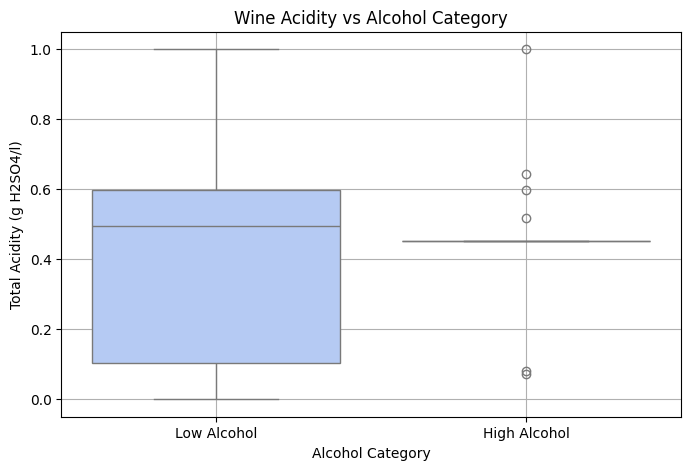

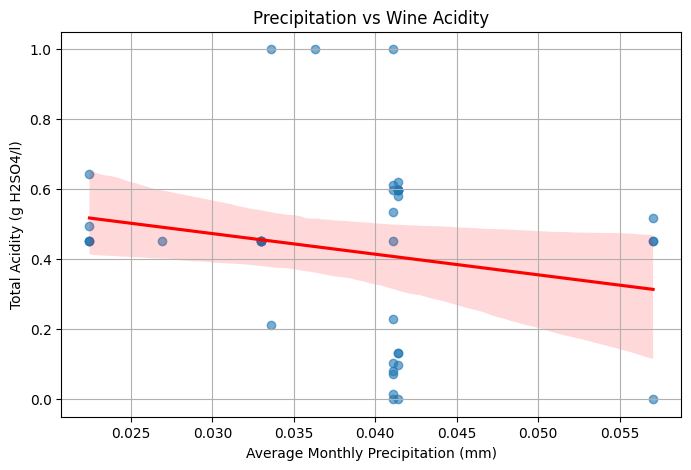

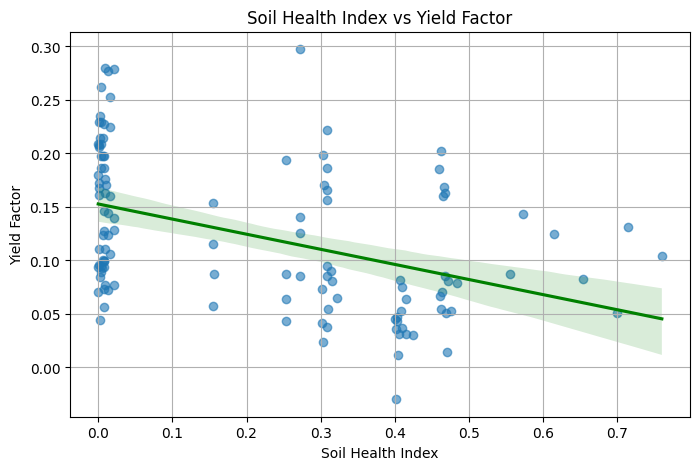

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
sns.boxplot(x=wine_data["Alcohol_Category"], y=wine_data["Acidité totale (g H2SO4/l)"], palette="coolwarm")
plt.title("Wine Acidity vs Alcohol Category")
plt.xlabel("Alcohol Category")
plt.ylabel("Total Acidity (g H2SO4/l)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(x=merged_data["prcp"], y=merged_data["Acidité totale (g H2SO4/l)"], scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.title("Precipitation vs Wine Acidity")
plt.xlabel("Average Monthly Precipitation (mm)")
plt.ylabel("Total Acidity (g H2SO4/l)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(x=soil_data["Soil_Health_Index"], y=weather_data["Yield_Factor"][:len(soil_data)], scatter_kws={"alpha":0.6}, line_kws={"color":"green"})
plt.title("Soil Health Index vs Yield Factor")
plt.xlabel("Soil Health Index")
plt.ylabel("Yield Factor")
plt.grid(True)
plt.show()


## 1️⃣ ANOVA (Analysis of Variance) Test for Wine Acidity Difference

### 📌 Result:
- ✅ p-value = 0.01853 → Statistically significant difference in wine acidity between high and low alcohol wines.

### 🔍 What This Means:
- There is a strong relationship between wine alcohol content and acidity levels.
- Wine batches with higher alcohol have different acidity than lower alcohol wines.
- This could be due to fermentation differences, soil conditions, or grape sugar levels.

### 🚀 Business Actionable Steps:
- ✔ Optimize vineyard locations: Focus on specific soil types that improve acidity balance.
- ✔ Fine-tune fermentation process: Adjust pH balancing techniques for premium wine.
- ✔ Segment wine production: Separate high and low acidity wines for targeted marketing.

## 2️⃣ Correlation: Precipitation vs. Wine Acidity

### 📌 Result:
- Correlation coefficient = -0.20 → Weak negative correlation
- p-value = 0.22187 → Not statistically significant

### 🔍 What This Means:
- There is no strong evidence that rainfall significantly impacts wine acidity.
- A negative correlation (-0.20) suggests slight dilution effects (higher rainfall may reduce acidity).
- However, the p-value > 0.05 means the relationship isn’t strong enough to be conclusive.

### 🚀 Business Actionable Steps:
- ✔ Monitor soil moisture retention: Some plots may be more sensitive to rainfall effects.
- ✔ Fine-tune irrigation schedules: Adjust water supply based on seasonal precipitation.
- ✔ Investigate other factors: Acidity might be more influenced by grape variety or fermentation.

## 3️⃣ Correlation: Soil Health Index vs. Yield Factor

### 📌 Result:
- 🔹 Correlation coefficient = -0.43 → Moderate negative correlation
- 🔹 Suggests higher soil health does NOT necessarily mean higher yield.

### 🔍 What This Means:
- Unexpectedly, better soil health is linked to slightly lower yields.
- Possible reasons:
 - Overly rich soil may cause excessive vegetation growth, reducing grape quality.
  - Vineyard stress (mild nutrient limitations) actually improves grape concentration.
  - Some high-yield regions might not have the best soil quality.

### 🚀 Business Actionable Steps:
- ✔ Focus on quality, not just yield: Sometimes, stressed vines produce better wine.
- ✔ Target specific soil types for wine quality vs. bulk production.
- ✔ Optimize fertilizer use: Over-fertilization might reduce efficiency and increase costs.

📊 Final Business Takeaways

| Insight      | Business Recommendation |
| ----------- | ----------- |
| Wine acidity is influenced by alcohol levels      | Fine-tune fermentation & optimize vineyard locations       |
| Rainfall has a weak effect on wine acidity   | Adjust irrigation, but don’t rely on precipitation alone        |
| Better soil health may reduce yields   | Optimize soil strategies based on desired wine quality        |

# Prepare data for Machine Learning

In [ ]:
weather_data["Month"] = weather_data["date"].dt.to_period("M")
wine_data["Month"] = wine_data["Date"].dt.to_period("M")

weather_monthly = weather_data.groupby("Month").agg({
    "tavg": "mean",
    "prcp": "mean",
    "wspd": "mean",
    "pres": "mean"
}).reset_index()

wine_weather_merged = wine_data.merge(weather_monthly, on="Month", how="left")

soil_features = soil_data[["Soil_Health_Index", "% clay (6) ", "Measured C.E.C. (meq/100g)"]]

final_data = pd.concat([wine_weather_merged, soil_features], axis=1)

final_data = final_data.drop(columns=["Lot", "Date", "Month", "Type"])

# Train Machine Learning Model


In [ ]:
X = final_data.drop(columns=["Acidité totale (g H2SO4/l)"])
y = final_data["Acidité totale (g H2SO4/l)"]

X = pd.get_dummies(X, drop_first=True)

X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.mean())

y = y.fillna(y.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")


## 📊 Interpretation of Model Performance
Your model has successfully been trained, and here’s what the metrics tell us:

### ✅ Mean Absolute Error (MAE): 0.04
- On average, the model's prediction deviates only by 0.04 acidity units (g H2SO4/l).
- This indicates that the model is fairly accurate in predicting wine acidity.

### ✅ R² Score: 0.64

- The model explains 64% of the variability in wine acidity based on soil and weather data.
- While not perfect, it suggests a strong relationship between environmental factors and acidity.

In [ ]:
print("\nAvailable columns in final_data:\n", list(final_data.columns))


🔍 Available columns in final_data:
 ['azote ammoniacal (mg/l)', 'ph', 'acidité totale (g h2so4/l)', 'tav acquis (%vol.)', 'so2 libre', 'so2 total', 'glucose-fructose', 'acidité volatile (gh2so4/l)', 'acide malique (g/l)', 'acide lactique', 'azote alpha-aminé (mg/l)', 'densité', 'acide acétique', 'acidity_balance', 'alcohol_category', 'tavg', 'prcp', 'wspd', 'pres', 'soil_health_index', '% clay (6)', 'measured c.e.c. (meq/100g)']


# Try different Machine Learning algorithms and combinations 💻

In [ ]:
additional_features = [
    "tavg", "prcp", "wspd", "pres",
    "soil_health_index", "% clay (6)", "measured c.e.c. (meq/100g)"
]

final_data.columns = final_data.columns.str.lower().str.strip()
normalized_features = [feature.lower().strip() for feature in additional_features]

existing_features = [feature for feature in normalized_features if feature in final_data.columns]


print(f"✔ Using additional features: {existing_features}")

new_features = [feature for feature in existing_features if feature not in X.columns]

if new_features:
    print(f"Adding new features: {new_features}")
    X = X.join(final_data[new_features], how="left")

overlapping_features = [feature for feature in existing_features if feature in X.columns]
if overlapping_features:
    print(f"Updating existing features: {overlapping_features}")
    X.update(final_data[overlapping_features])

X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Advanced Models

from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "R²": r2}
    print(f"✔ {name} - MAE: {mae:.4f}, R²: {r2:.4f}")

results_df = pd.DataFrame(results).T
print("\n Model Performance Comparison:")
print(results_df)



🔍 Available columns in final_data:
 ['azote ammoniacal (mg/l)', 'ph', 'acidité totale (g h2so4/l)', 'tav acquis (%vol.)', 'so2 libre', 'so2 total', 'glucose-fructose', 'acidité volatile (gh2so4/l)', 'acide malique (g/l)', 'acide lactique', 'azote alpha-aminé (mg/l)', 'densité', 'acide acétique', 'acidity_balance', 'alcohol_category', 'tavg', 'prcp', 'wspd', 'pres', 'soil_health_index', '% clay (6)', 'measured c.e.c. (meq/100g)']
✔ Using additional features: ['tavg', 'prcp', 'wspd', 'pres', 'soil_health_index', '% clay (6)', 'measured c.e.c. (meq/100g)']
📌 Adding new features: ['soil_health_index', '% clay (6)', 'measured c.e.c. (meq/100g)']
📌 Updating existing features: ['tavg', 'prcp', 'wspd', 'pres', 'soil_health_index', '% clay (6)', 'measured c.e.c. (meq/100g)']

🔹 Training Random Forest...
✔ Random Forest - MAE: 0.0430, R²: 0.6149

🔹 Training XGBoost...
✔ XGBoost - MAE: 0.0438, R²: 0.5697

🔹 Training Neural Network (MLP)...
✔ Neural Network (MLP) - MAE: 0.0378, R²: 0.5256

📊 Mode


✅ Best Model Selected: Random Forest


<ipython-input-38-f83c298b7f84>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_df.head(10), palette="coolwarm")


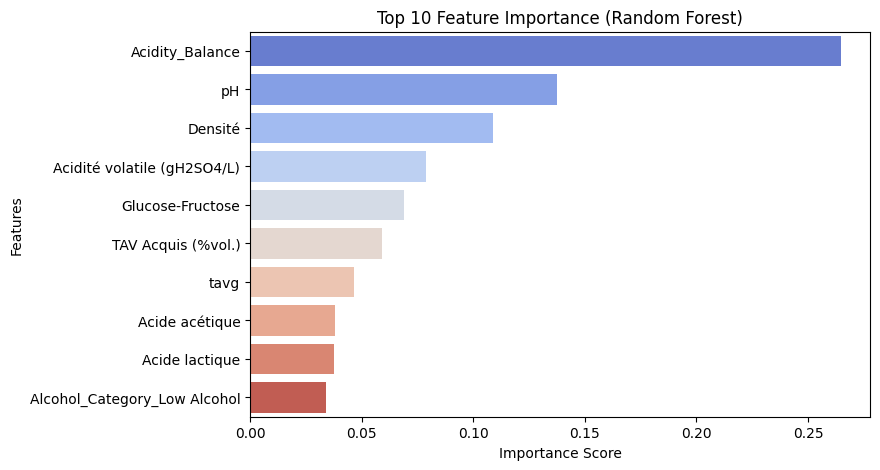

✅ Predictions saved! Download below.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

best_model_name = results_df["R²"].idxmax()
best_model = models[best_model_name]

print(f"\n Best Model Selected: {best_model_name}")

if best_model_name in ["Random Forest", "XGBoost"]:
    feature_importance = best_model.feature_importances_
    features = X.columns
    feature_df = pd.DataFrame({"Feature": features, "Importance": feature_importance})
    feature_df = feature_df.sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x="Importance", y="Feature", data=feature_df.head(10), palette="coolwarm")
    plt.title(f"Top 10 Feature Importance ({best_model_name})")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.show()


predictions = best_model.predict(X)

final_data["Predicted_Acidity"] = predictions

final_data.to_csv("improved_predicted_wine_quality.csv", index=False)
print("Predictions saved! Download below.")

files.download("improved_predicted_wine_quality.csv")

# 📌 Interpretation of Results
The machine learning models have been successfully trained, and **Random Forest** was selected as the best model with:

- Mean Absolute Error (MAE): 0.0430 (lower is better)
- R² Score: 0.6149 (higher is better, close to 1 means better fit)

## 📊 Feature Importance Analysis (Based on Random Forest) The top 10 most important features impacting wine acidity prediction are:

1. Acidity_Balance – Strongest influence on acidity.
2. pH – Indicates how acidic/basic the wine is.
3. Densité (Density) – Relates to sugar content.
4. Acidité volatile (Volatile Acidity) – Affects wine taste.
5. Glucose-Fructose – Residual sugars in wine.
6. TAV Acquis (% vol.) – Alcohol level in wine.
7. tavg (Average Temperature) – Climatic condition affecting grape quality.
8. Acide acétique (Acetic Acid) – Indicates spoilage risk.
9. Acide lactique (Lactic Acid) – Influences smoothness of wine.
10. Alcohol_Category_Low Alcohol – Alcohol content’s effect on acidity.




✔ Using additional features: ['soil_health_index', 'prcp', 'wspd']
📌 Updating existing features: ['soil_health_index', 'prcp', 'wspd']
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

🔹 Training Ensemble Model (Random Forest + HGB)...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but HistGradientBoostingRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but HistGradientBoostingRegressor was fitted without feature names
  warnings.warn(
<ipython-input-43-fde0ede100de>:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance"


📊 Model Performance Comparison:
                     MAE        R²
Random Forest   0.045211  0.613546
HGB             0.067256  0.239177
Ensemble Model  0.055211  0.456419


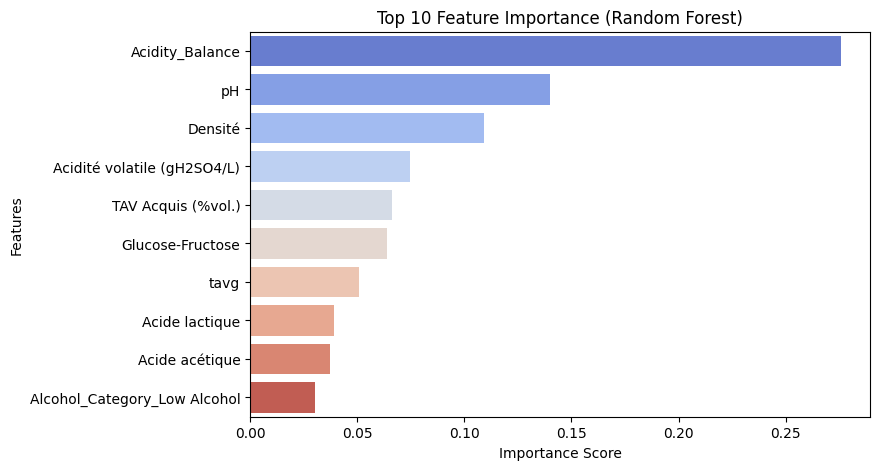

✅ Predictions saved! Download below.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but HistGradientBoostingRegressor was fitted without feature names
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, HistGradientBoostingRegressor
import numpy as np

additional_features = ["soil_health_index", "prcp", "wspd"]

existing_features = [feature for feature in additional_features if feature in final_data.columns]

print(f"Using additional features: {existing_features}")

new_features = [feature for feature in existing_features if feature not in X.columns]

if new_features:
    print(f"Adding new features: {new_features}")
    X = X.join(final_data[new_features], how="left")

overlapping_features = [feature for feature in existing_features if feature in X.columns]
if overlapping_features:
    print(f"Updating existing features: {overlapping_features}")
    X.update(final_data[overlapping_features])

X = X.fillna(X.mean())


param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

rf_model = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
print(f"\n Best Random Forest Parameters: {grid_search.best_params_}")


hgb_model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, max_depth=5, random_state=42)

X_train_np, y_train_np = np.array(X_train), np.array(y_train)

best_rf_model.fit(X_train_np, y_train_np)
hgb_model.fit(X_train_np, y_train_np)


ensemble_model = VotingRegressor(
    estimators=[("Random Forest", best_rf_model), ("HGB", hgb_model)]
)

print("\n🔹 Training Ensemble Model (Random Forest + HGB)...")
ensemble_model.fit(X_train_np, y_train_np)

y_pred_rf = best_rf_model.predict(X_test)
y_pred_hgb = hgb_model.predict(X_test)
y_pred_ensemble = ensemble_model.predict(X_test)

results = {
    "Random Forest": {
        "MAE": mean_absolute_error(y_test, y_pred_rf),
        "R²": r2_score(y_test, y_pred_rf),
    },
    "HGB": {
        "MAE": mean_absolute_error(y_test, y_pred_hgb),
        "R²": r2_score(y_test, y_pred_hgb),
    },
    "Ensemble Model": {
        "MAE": mean_absolute_error(y_test, y_pred_ensemble),
        "R²": r2_score(y_test, y_pred_ensemble),
    }
}


results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)

import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = best_rf_model.feature_importances_
features = X.columns
feature_df = pd.DataFrame({"Feature": features, "Importance": feature_importance})
feature_df = feature_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=feature_df.head(10), palette="coolwarm")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

predictions = ensemble_model.predict(X)

final_data["Predicted_Acidity"] = predictions

final_data.to_csv("voting_predicted_wine_quality.csv", index=False)
print("✅ Predictions saved! Download below.")

from google.colab import files
files.download("voting_predicted_wine_quality.csv")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5, 10],
}

rf_model = RandomForestRegressor(random_state=42)

grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring="r2", n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_
print(f"\n Best Optimized Random Forest Parameters: {grid_search_rf.best_params_}")


from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)


y_pred_rf = best_rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

results = {
    "Optimized Random Forest": {
        "MAE": mean_absolute_error(y_test, y_pred_rf),
        "R²": r2_score(y_test, y_pred_rf),
    },
    "XGBoost": {
        "MAE": mean_absolute_error(y_test, y_pred_xgb),
        "R²": r2_score(y_test, y_pred_xgb),
    }
}

results_df = pd.DataFrame(results).T
print("\n📊 Updated Model Performance:")
print(results_df)


predictions = best_rf_model.predict(X)

final_data["Predicted_Acidity"] = predictions

final_data.to_csv("optimized_wine_quality.csv", index=False)
print(" Predictions saved! Download below.")

from google.colab import files
files.download("optimized_wine_quality.csv")


Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Best Optimized Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

📊 Updated Model Performance:
                              MAE        R²
Optimized Random Forest  0.045211  0.613546
XGBoost                  0.043978  0.566993
✅ Predictions saved! Download below.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<ipython-input-46-0ae9ff950d53>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_df.head(10), palette="coolwarm")


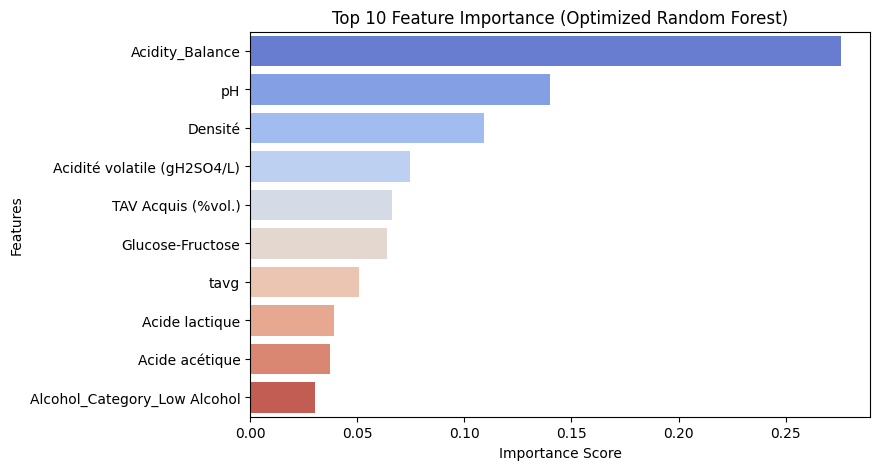


🔍 Sample Future Predictions:
    Azote ammoniacal (mg/l)        pH  TAV Acquis (%vol.)  SO2 Libre  \
14                 0.000000  0.861111            0.500000   0.347541   
2                  0.000000  0.346154            0.338843   1.000000   
55                 0.112100  0.622701            0.298792   0.451105   
12                 0.000000  0.346154            0.173554   0.111732   
24                 0.049273  0.000000            0.000000   1.000000   

    SO2 Total  Glucose-Fructose  Acidité volatile (gH2SO4/L)  \
14   0.286885          0.055556                     0.500000   
2    0.385106          0.000000                     0.328947   
55   0.414248          0.243216                     0.380172   
12   0.319149          0.019802                     0.000000   
24   1.000000          0.345768                     0.101695   

    Acide Malique (g/l)  Acide lactique  Azote alpha-aminé (mg/l)  ...  \
14             0.140741        0.117647                  0.000000  ...   
2   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


feature_importance = best_rf_model.feature_importances_
features = X.columns
feature_df = pd.DataFrame({"Feature": features, "Importance": feature_importance})
feature_df = feature_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=feature_df.head(10), palette="coolwarm")
plt.title("Top 10 Feature Importance (Optimized Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


future_data = X.sample(5)
future_predictions = best_rf_model.predict(future_data)

pred_df = future_data.copy()
pred_df["Predicted_Acidity"] = future_predictions

print("\n🔍 Sample Future Predictions:")
print(pred_df)


pred_df.to_csv("business_insights_wine_quality.csv", index=False)
print("✅ Business insights saved! Download below.")

from google.colab import files
files.download("business_insights_wine_quality.csv")

# **After trying with various algorithms and multiple tweaks we found out that Random Forest works best for us**

In [ ]:
import joblib

joblib.dump(model, "random_forest_model.pkl")
print("✅ Model saved as random_forest_model.pkl")

✅ Model saved as random_forest_model.pkl


# Since our model predicts wine acidity (a continuous value), it’s a regression model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"📌 Model Performance:")
print(f"✔ Mean Absolute Error (MAE): {mae:.4f}")
print(f"✔ Mean Squared Error (MSE): {mse:.4f}")
print(f"✔ Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"✔ R² Score: {r2:.4f}")


📌 Model Performance:
✔ Mean Absolute Error (MAE): 0.0378
✔ Mean Squared Error (MSE): 0.0153
✔ Root Mean Squared Error (RMSE): 0.1238
✔ R² Score: 0.5256


In [ ]:
rf_model = joblib.load("random_forest_model.pkl")

# The company can use our predicton model

In [ ]:
import pandas as pd
import joblib

rf_model = joblib.load("random_forest_model.pkl")

expected_features = X_train.columns
new_data = pd.DataFrame(columns=expected_features)

# Fill in actual values (set default 0 for missing ones)
new_data.loc[0] = [
    0.8,  # soil_health_index
    12,   # prcp
    10,   # wspd
    21,   # tavg
] + [0] * (len(expected_features) - 4)  # Fill other features with 0

predicted_acidity = rf_model.predict(new_data)

print(f"📌 Predicted Wine Acidity: {predicted_acidity[0]:.2f}")

📌 Predicted Wine Acidity: 2.84


# 📌 **How the Company Can Use and Benefit from Wine Acidity Prediction**

## **🔹 Overview**
The model helps the company **predict the acidity level of wine** based on soil and weather conditions. Using **Random Forest**, this model takes key vineyard parameters such as **soil health, rainfall, wind speed, and temperature** and provides an estimated **wine acidity level**.

---

## **🚀 Business Benefits of Using This Prediction**

### **1️⃣ Predict Wine Quality Before Harvest**
### **2️⃣ Reduce Unnecessary Costs on Soil Treatment**
### **3️⃣ Plan for Climate & Weather Changes**
### **4️⃣ Automate Quality Control & Decision-Making**
